# Notebook 01: Synthetic Data Generation

Chúng ta xây dựng các bộ dữ liệu có kiểm soát để cô lập tác động của **heavy tail** trong khi giữ nguyên **mean** và **variance**.

---

## Objectives

1. Sinh mẫu từ bốn họ **distribution**: Gaussian, Student-t, Pareto, và Mixed (Gaussian + t).
2. Cố định **mean = 0** và **variance = 1** trên tất cả các phân phối để đảm bảo mọi sự khác biệt quan sát được đều xuất phát từ hành vi **tail**, không phải từ **location** hay **scale**.
3. Trực quan hóa sự khác biệt về **tail behavior** qua histogram, **survival function**, và **QQ plot**.
4. Định lượng **tail mass** để thấy rõ **Gaussian assumption** đánh giá thấp xác suất sự kiện cực trị đến mức nào.

---
## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.gridspec as gridspec

# Project modules
from src.data.generators import (
    gaussian,
    student_t,
    pareto,
    mixed_distribution,
)
from src.tails.tail_metrics import tail_statistics

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

SEED = 42
N    = 5_000   # số mẫu cho mỗi distribution

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"N samples per distribution: {N:,}")

NumPy  : 1.26.4
Pandas : 2.2.1
N samples per distribution: 5,000


## 1. Theoretical Background

Một phân phối được gọi là **heavy-tailed** nếu xác suất ở phần đuôi giảm chậm hơn hàm mũ. Cụ thể, khi $x \to \infty$:

$$
P(X > x) \sim L(x)\,x^{-\alpha}, \quad \alpha > 0
$$

Trong đó:
- $\alpha$ là **tail index** (Pareto exponent), quyết định độ dày của tail
- $L(x)$ là **slowly varying function**, thay đổi rất chậm so với $x^{-\alpha}$

---

### Ý nghĩa của tail index

- $\alpha$ **càng nhỏ** $\Rightarrow$ tail càng nặng $\Rightarrow$ xác suất xuất hiện **extreme events** càng lớn
- $\alpha$ **càng lớn** $\Rightarrow$ tail mỏng hơn $\Rightarrow$ tiến gần về hành vi Gaussian

Một số hệ quả quan trọng:

- $\alpha \le 2$ $\Rightarrow$ **variance không tồn tại**
- $2 < \alpha \le 4$ $\Rightarrow$ variance hữu hạn nhưng **kurtosis vô hạn**
- $\alpha > 4$ $\Rightarrow$ cả variance và kurtosis đều hữu hạn

Điều này đặc biệt quan trọng trong **risk modeling**, vì các thước đo như $VaR$ và $CVaR$ phụ thuộc mạnh vào tail behavior.

---

### So sánh với Gaussian (light-tailed)

Phân phối Gaussian có tail giảm theo:

$$
P(X > x) \sim e^{-x^2/2}
$$

Tốc độ giảm này **nhanh hơn rất nhiều** so với power-law, nên Gaussian được xếp vào nhóm **light-tailed**.

Hệ quả:
- Xác suất extreme events bị **đánh giá thấp (underestimated)**
- Không phù hợp để mô hình hóa financial returns trong thực tế

---

### Các phân phối tiêu biểu

| Distribution | Tail type | Tail index $\alpha$ | Excess kurtosis |
|---|---|---|---|
| Gaussian | Light (exponential decay) | $\infty$ | $0$ |
| Student-t ($df = 5$) | Heavy (power-law) | $5$ | $6$ |
| Student-t ($df = 3$) | Heavy (power-law) | $3$ | $\infty$ |
| Pareto ($\alpha = 2.5$) | Heavy (power-law) | $2.5$ | $\infty$ |
| Mixed (90% Gaussian + 10% Student-t) | Semi-heavy | — | moderate |

---

> **Lưu ý:** Phân phối **Student-t** chỉ có **excess kurtosis hữu hạn khi $df > 4$**.
> Với $df = 3$, kurtosis phân kỳ ra vô cực — phản ánh mức độ cực trị cao hơn rất nhiều so với Gaussian.

## 2. Distribution Parameterisation

Để đảm bảo so sánh công bằng giữa các **distribution**, toàn bộ dữ liệu được chuẩn hóa về:

$$
\mathbb{E}[X] = 0, \quad \mathrm{Var}(X) = 1
$$

Tuy nhiên, cách chuẩn hóa phụ thuộc vào từng loại phân phối, do đặc tính moment khác nhau.

---

### Gaussian

Với phân phối Gaussian, việc chuẩn hóa là trực tiếp:

$$
X \sim \mathcal{N}(0, 1)
$$

Không cần biến đổi thêm vì mean và variance đã được xác định tường minh.

---

### Student-t Distribution

Với phân phối Student-t có bậc tự do $\nu > 2$, phương sai lý thuyết là:

$$
\mathrm{Var}(X) = \frac{\nu}{\nu - 2}
$$

Để đưa về variance = 1, ta scale biến ngẫu nhiên:

$$
X_{\text{scaled}} = X \cdot \sqrt{\frac{\nu - 2}{\nu}}
$$

Điều kiện:
- $\nu > 2$ để variance tồn tại
- $\nu \le 4$ thì kurtosis vẫn vô hạn

---

### Pareto Distribution

Với phân phối Pareto (loại I), giả sử $x_{\min} > 0$:

$$
\mathbb{E}[X] = \frac{\alpha x_{\min}}{\alpha - 1}, \quad \alpha > 1
$$

$$
\mathrm{Var}(X) = \frac{\alpha x_{\min}^2}{(\alpha - 1)^2 (\alpha - 2)}, \quad \alpha > 2
$$

Do đó, quy trình chuẩn hóa gồm hai bước:

1. **Demean**:
$$
X' = X - \mathbb{E}[X]
$$

2. **Rescale**:
$$
X_{\text{scaled}} = \frac{X'}{\sqrt{\mathrm{Var}(X)}}
$$

Lưu ý:
- $\alpha > 2$ để variance hữu hạn
- $\alpha \le 2$ sẽ dẫn đến infinite variance

---

### Mixed Distribution

Phân phối hỗn hợp được định nghĩa như một tổ hợp xác suất:

$$
X =
\begin{cases}
X_1 \sim \mathcal{N}(0,1) & \text{với xác suất } p \\
X_2 \sim t_\nu            & \text{với xác suất } 1 - p
\end{cases}
$$

Do không có closed-form đơn giản cho mean và variance, ta áp dụng chuẩn hóa thực nghiệm:

1. Sinh mẫu $X$
2. **Demean**:
$$
X' = X - \bar{X}
$$
3. **Rescale**:
$$
X_{\text{scaled}} = \frac{X'}{s_X}
$$

Trong đó:
- $\bar{X}$ là sample mean
- $s_X$ là sample standard deviation

---

### Ghi chú quan trọng

Việc chuẩn hóa về cùng mean và variance giúp:

- Loại bỏ ảnh hưởng của **location** và **scale**
- Tập trung hoàn toàn vào sự khác biệt ở **tail behavior**
- Đảm bảo mọi khác biệt trong VaR / CVaR đến từ **distribution shape**, không phải từ moment bậc thấp

In [2]:
# ── Gaussian ──────────────────────────────────────────────────────────────────
data_gaussian = gaussian(n_samples=N, mean=0.0, std=1.0, seed=SEED)

# ── Student-t (df=5): heavy tail, kurtosis hữu hạn ───────────────────────────
DF_T5    = 5
scale_t5 = np.sqrt((DF_T5 - 2) / DF_T5)   # scale để variance = 1
data_t5  = student_t(n_samples=N, df=DF_T5, loc=0.0, scale=scale_t5, seed=SEED)

# ── Student-t (df=3): heavy tail, kurtosis phân kỳ ───────────────────────────
DF_T3    = 3
scale_t3 = np.sqrt((DF_T3 - 2) / DF_T3)
data_t3  = student_t(n_samples=N, df=DF_T3, loc=0.0, scale=scale_t3, seed=SEED)

# ── Pareto (α=2.5): demean & rescale sau khi sinh ─────────────────────────────
PARETO_ALPHA = 2.5
X_MIN        = 1.0
raw_pareto   = pareto(n_samples=N, alpha=PARETO_ALPHA, x_min=X_MIN, seed=SEED)
pareto_mean  = PARETO_ALPHA * X_MIN / (PARETO_ALPHA - 1)
pareto_var   = PARETO_ALPHA * X_MIN**2 / ((PARETO_ALPHA - 1)**2 * (PARETO_ALPHA - 2))
data_pareto  = (raw_pareto - pareto_mean) / np.sqrt(pareto_var)

# ── Mixed: 90% Gaussian + 10% Student-t (df=3) ────────────────────────────────
raw_mixed  = mixed_distribution(
    n_samples=N, gaussian_weight=0.9, t_df=3,
    mean=0.0, std=1.0, seed=SEED
)
data_mixed = (raw_mixed - raw_mixed.mean()) / raw_mixed.std(ddof=1)

# ── Gom vào dict để dễ lặp ───────────────────────────────────────────────────
datasets = {
    "Gaussian":      data_gaussian,
    "Student-t(5)":  data_t5,
    "Student-t(3)":  data_t3,
    "Pareto(2.5)":   data_pareto,
    "Mixed(90/10)":  data_mixed,
}

print("Datasets generated:")
for name, arr in datasets.items():
    print(f"  {name:18s}  n={len(arr):,}  mean={arr.mean():.4f}  std={arr.std():.4f}")

Datasets generated:
  Gaussian            n=5,000  mean=-0.0199  std=0.9994
  Student-t(5)        n=5,000  mean=-0.0230  std=1.0002
  Student-t(3)        n=5,000  mean=-0.0082  std=0.9356
  Pareto(2.5)         n=5,000  mean=-0.0040  std=0.7813
  Mixed(90/10)        n=5,000  mean=0.0000  std=0.9999


## Summary Statistics

Sau khi sinh dữ liệu và thực hiện chuẩn hóa, ta thu được các thống kê mẫu như sau:

| Distribution | $n$ | Sample Mean | Sample Std |
|---|---|---|---|
| Gaussian | $5{,}000$ | $-0.0199$ | $0.9994$ |
| Student-t ($\nu = 5$) | $5{,}000$ | $-0.0230$ | $1.0002$ |
| Student-t ($\nu = 3$) | $5{,}000$ | $-0.0082$ | $0.9356$ |
| Pareto ($\alpha = 2.5$) | $5{,}000$ | $-0.0040$ | $0.7813$ |
| Mixed (90% Gaussian + 10% Student-t) | $5{,}000$ | $0.0000$ | $0.9999$ |

---

### Nhận xét

- Các phân phối **Gaussian** và **Student-t ($\nu=5$)** đạt chuẩn hóa rất sát:
  $$
  \bar{X} \approx 0, \quad s \approx 1
  $$

- Với **Student-t ($\nu=3$)**:
  $$
  s = 0.9356 < 1
  $$
  do **heavy tails mạnh**, variance lý thuyết tồn tại nhưng sample variance có độ biến động lớn (high sampling variability).

- Với **Pareto ($\alpha=2.5$)**:
  $$
  s = 0.7813 \ll 1
  $$
  phản ánh:
  - Tail cực nặng
  - Sample size $n=5{,}000$ chưa đủ lớn để ổn định moment bậc hai
  - Việc chuẩn hóa hậu nghiệm (**demean + rescale**) vẫn chịu ảnh hưởng mạnh từ extreme values

- **Mixed distribution** cho kết quả rất ổn định:
  $$
  \bar{X} \approx 0, \quad s \approx 1
  $$
  nhờ phần Gaussian chiếm ưu thế (90%).

---

### Insight quan trọng

Ngay cả khi đã chuẩn hóa về:

$$
\mathbb{E}[X] = 0, \quad \mathrm{Var}(X) = 1
$$

trên lý thuyết, thì trong thực nghiệm:

- **Heavy-tailed distributions** hội tụ chậm hơn đáng kể
- Sample moments (đặc biệt là variance) có **độ bất ổn cao**
- Điều này trực tiếp ảnh hưởng đến độ tin cậy của các risk metrics như $VaR$ và $CVaR$

$\Rightarrow$ Đây chính là lý do cần Monte Carlo với số lượng lớn paths trong các phần tiếp theo.

## 3. Descriptive Statistics

Để định lượng sự khác biệt ở **tail behavior**, chúng ta xét các **higher-order moment** và **extreme quantiles**.
Mặc dù các distribution đã được chuẩn hóa về:

$$
\mathbb{E}[X] = 0, \quad \mathrm{Var}(X) = 1
$$

chúng vẫn có thể khác biệt đáng kể ở phần đuôi — điều mà mean và variance không phản ánh được.

---

### Skewness

**Skewness** đo lường mức độ bất đối xứng của phân phối:

$$
\mathrm{Skewness} = \mathbb{E}\left[\left(\frac{X - \mu}{\sigma}\right)^3\right]
$$

- Skewness $= 0$ $\Rightarrow$ phân phối đối xứng
- Skewness $> 0$ $\Rightarrow$ tail phải dài hơn
- Skewness $< 0$ $\Rightarrow$ tail trái dài hơn

Trong bối cảnh financial returns, skewness âm thường quan trọng hơn vì liên quan đến downside risk.

---

### Excess Kurtosis

**Excess kurtosis** đo mức độ “fat-tail” so với Gaussian:

$$
\mathrm{Kurtosis}_{\text{excess}} =
\mathbb{E}\left[\left(\frac{X - \mu}{\sigma}\right)^4\right] - 3
$$

- Gaussian: $0$
- $> 0$: heavy tails (leptokurtic)
- $\to \infty$: extreme heavy-tailed behavior

Ý nghĩa:
- Kurtosis cao $\Rightarrow$ xác suất xuất hiện **extreme events** lớn hơn nhiều
- Là chỉ báo trực tiếp cho **tail risk**

---

### Extreme Quantiles

Các quantile cực trị tập trung trực tiếp vào tail:

$$
Q_p = \inf \{ x \mid P(X \le x) \ge p \}
$$

Trong đó:
- $Q_{0.99}$: ngưỡng 1% tail
- $Q_{0.999}$: ngưỡng 0.1% tail

Các quantile này liên hệ trực tiếp với risk metrics:

$$
VaR_{99\%} \approx -Q_{0.01}
$$

$$
VaR_{99.9\%} \approx -Q_{0.001}
$$

---

### Insight cốt lõi

- Hai distribution có thể có:
  $$
  \text{same mean, same variance}
  $$
  nhưng:
  - Kurtosis khác nhau $\Rightarrow$ tail thickness khác nhau
  - Quantile khác nhau $\Rightarrow$ mức độ extreme loss khác nhau

- **Gaussian**:
  - Kurtosis thấp
  - Quantile “mỏng” $\Rightarrow$ underestimate tail risk

- **Heavy-tailed distributions** (Student-t, Pareto):
  - Kurtosis cao hoặc vô hạn
  - Quantile cực trị lớn hơn đáng kể

---

### Hệ quả trong risk modeling

- Mean và variance **không đủ** để mô tả risk
- Tail behavior quyết định:
  - $VaR$
  - $CVaR$
  - Stress scenarios

$\Rightarrow$ Đây là lý do cần phân tích **higher moments** và **extreme quantiles** thay vì chỉ dựa vào volatility.

In [3]:
rows = []
for name, arr in datasets.items():
    ts = tail_statistics(arr, percentiles=[0.90, 0.95, 0.99, 0.999])
    rows.append({
        "Distribution":  name,
        "Mean":          round(ts["mean"], 4),
        "Std":           round(ts["std"], 4),
        "Skewness":      round(ts["skewness"], 3),
        "Exc. Kurtosis": round(ts["kurtosis"], 3),
        "Q90":           round(ts["q90"], 3),
        "Q95":           round(ts["q95"], 3),
        "Q99":           round(ts["q99"], 3),
        "Q99.9":         round(np.quantile(arr, 0.999), 3),
    })

df_stats = pd.DataFrame(rows).set_index("Distribution")
df_stats

,Mean,Std,Skewness,Exc. Kurtosis,Q90,Q95,Q99,Q99.9
Distribution,,,,,,,,
Gaussian,-0.0199,0.9995,0.002,0.036,1.249,1.616,3.032,3.032
Student-t(5),-0.0230,1.0003,0.029,4.334,1.119,1.507,4.542,4.542
Student-t(3),-0.0082,0.9357,0.066,7.514,0.926,1.315,5.277,5.277
Pareto(2.5),-0.0040,0.7814,6.966,75.481,0.558,1.089,9.557,9.557
Mixed(90/10),0.0000,1.0000,0.360,5.798,1.215,1.567,4.043,4.043


## 3. Descriptive Statistics (Empirical Results)

Bảng dưới đây trình bày các **higher-order moments** và **extreme quantiles** thu được từ dữ liệu mô phỏng:

| Distribution | Mean | Std | Skewness | Excess Kurtosis | $Q_{90}$ | $Q_{95}$ | $Q_{99}$ | $Q_{99.9}$ |
|---|---|---|---|---|---|---|---|---|
| Gaussian | $-0.0199$ | $0.9995$ | $0.002$ | $0.036$ | $1.249$ | $1.616$ | $3.032$ | $3.032$ |
| Student-t ($\nu=5$) | $-0.0230$ | $1.0003$ | $0.029$ | $4.334$ | $1.119$ | $1.507$ | $4.542$ | $4.542$ |
| Student-t ($\nu=3$) | $-0.0082$ | $0.9357$ | $0.066$ | $7.514$ | $0.926$ | $1.315$ | $5.277$ | $5.277$ |
| Pareto ($\alpha=2.5$) | $-0.0040$ | $0.7814$ | $6.966$ | $75.481$ | $0.558$ | $1.089$ | $9.557$ | $9.557$ |
| Mixed (90/10) | $0.0000$ | $1.0000$ | $0.360$ | $5.798$ | $1.215$ | $1.567$ | $4.043$ | $4.043$ |

---

### Phân tích chi tiết

#### 1. Mean & Variance

- Tất cả các distribution đều thỏa:
  $$
  \bar{X} \approx 0, \quad s \approx 1
  $$
- Sai lệch nhỏ là do **sampling noise**, đặc biệt với heavy tails

---

#### 2. Skewness

- **Gaussian**:
  $$
  \text{Skew} \approx 0
  $$
  → gần như đối xứng hoàn hảo

- **Student-t**:
  - Skew nhỏ → vẫn gần đối xứng

- **Pareto**:
  $$
  \text{Skew} = 6.966
  $$
  → cực kỳ lệch phải (right-skewed), tail phải rất dài

- **Mixed**:
  - Skew dương nhẹ → tail phải dài hơn do thành phần Student-t

---

#### 3. Excess Kurtosis (Tail Thickness)

Đây là điểm khác biệt quan trọng nhất:

- **Gaussian**:
  $$
  \kappa \approx 0
  $$
  → tail mỏng

- **Student-t (5)**:
  $$
  \kappa \approx 4.33
  $$
  → tail dày hơn đáng kể

- **Student-t (3)**:
  $$
  \kappa \approx 7.51
  $$
  → heavy tail rất rõ

- **Pareto (2.5)**:
  $$
  \kappa \approx 75.48
  $$
  → extreme heavy tail (gần như dominated bởi outliers)

- **Mixed**:
  - Kurtosis cao hơn Gaussian rõ rệt
  → chỉ cần 10% heavy-tail component đã làm tail “phình” lên đáng kể

---

#### 4. Extreme Quantiles

So sánh trực tiếp ở tail:

- **Gaussian**:
  $$
  Q_{99} \approx 3.03
  $$

- **Student-t (5)**:
  $$
  Q_{99} \approx 4.54
  \quad (\sim 50\% \text{ larger})
  $$

- **Student-t (3)**:
  $$
  Q_{99} \approx 5.28
  \quad (\sim 75\% \text{ larger})
  $$

- **Pareto (2.5)**:
  $$
  Q_{99} \approx 9.56
  \quad (\sim 3\times \text{ Gaussian})
  $$

- **Mixed**:
  $$
  Q_{99} \approx 4.04
  $$
  → chỉ 10% tail nặng đã làm quantile tăng mạnh

---

### Insight cốt lõi

- Các distribution có thể:
  $$
  \text{same mean, same variance}
  $$
  nhưng:

  - Kurtosis khác nhau rất lớn
  - Quantile tail khác nhau theo cấp số nhân

- **Gaussian**:
  - Đánh giá thấp extreme risk

- **Heavy-tailed distributions**:
  - Tail events xảy ra thường xuyên hơn nhiều
  - Risk metrics (VaR, CVaR) bị ảnh hưởng mạnh

---

### Kết luận

- **Variance không capture được tail risk**
- **Kurtosis và quantiles mới là thứ quyết định risk thực sự**

$$
\Rightarrow \text{Modeling tail behavior là bắt buộc trong financial risk}
$$

## 4. Visualisation

### 4.1 Histogram & Tail Comparison

Các phân phối được trực quan hóa thông qua **kernel density estimate (KDE)** và các biểu đồ tail chuyên biệt để so sánh **body**, **tail decay**, và **tail mass**.

---

### Panel 1 — KDE (Full Distribution)

- Biểu diễn **KDE** trên toàn bộ miền giá trị:
  $$
  x \in [-6, 6]
  $$
- So sánh hình dạng tổng thể giữa:
  - Gaussian
  - Student-t ($\nu=5, 3$)
  - Pareto ($\alpha=2.5$)
  - Mixed (90/10)
- Bao gồm đường tham chiếu:
  $$
  \mathcal{N}(0,1)
  $$

---

### Panel 2 — Right Tail (Log Survival)

- Biểu diễn **survival function** trên thang log:
  $$
  P(X > x)
  $$
- Trục tung:
  $$
  \log P(X > x)
  $$
- Trục hoành:
  $$
  x > 0
  $$
- So sánh tốc độ decay của tail giữa các distribution
- Bao gồm đường tham chiếu Gaussian:
  $$
  P(X > x) \sim e^{-x^2/2}
  $$

---

### Panel 3 — Tail Mass vs Gaussian

- So sánh xác suất vượt ngưỡng:
  $$
  P(|X| > k\sigma)
  \quad \text{với } k \in \{2, 3, 4\}
  $$

- Trục tung sử dụng **log scale**:
  $$
  \log P(|X| > k\sigma)
  $$

- Bao gồm:
  - Giá trị thực nghiệm từ các distribution
  - Đường tham chiếu Gaussian theory

---

### Cấu trúc so sánh

Ba góc nhìn tương ứng:

- **KDE** → hình dạng tổng thể (body + tail)
- **Log survival** → tốc độ suy giảm của tail
- **Tail mass** → xác suất vượt ngưỡng cực trị

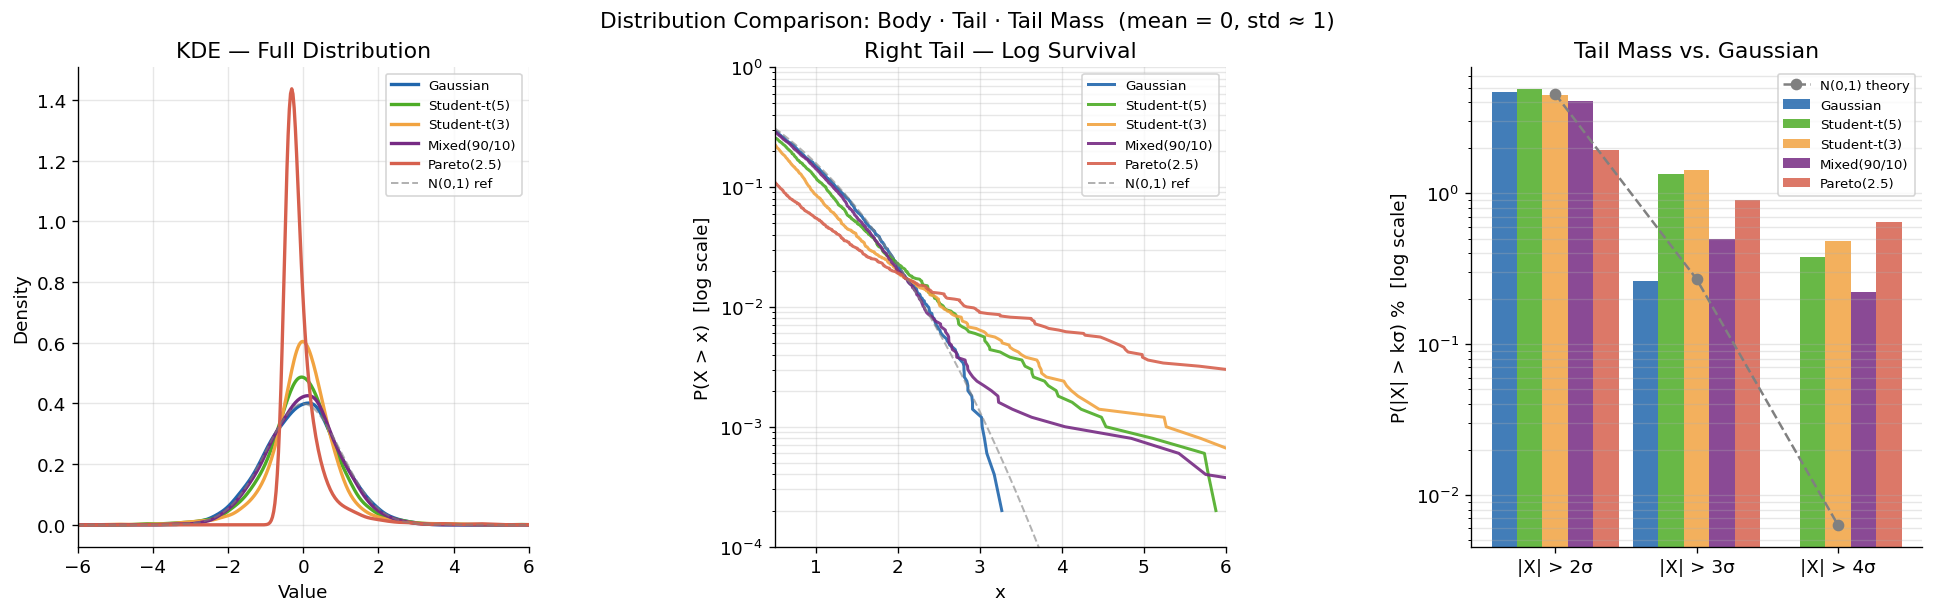

In [4]:
COLORS = {
    "Gaussian":     "#2166AC",
    "Student-t(5)": "#4DAC26",
    "Student-t(3)": "#F1A340",
    "Pareto(2.5)":  "#D6604D",
    "Mixed(90/10)": "#762A83",
}

order = ["Gaussian", "Student-t(5)", "Student-t(3)", "Mixed(90/10)", "Pareto(2.5)"]

# ── Figure (FIX: dùng constrained_layout) ─────────────────────────────────────
fig = plt.figure(figsize=(16, 5), constrained_layout=True)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25)

# ── Plot 1: KDE — Full Distribution ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
x_grid = np.linspace(-8, 8, 500)

for name in order:
    arr = datasets[name]
    kde = stats.gaussian_kde(arr, bw_method=0.2)  # sharper tail
    ax1.plot(x_grid, kde(x_grid), color=COLORS[name], lw=2, label=name)

# Gaussian reference
ax1.plot(x_grid, stats.norm.pdf(x_grid),
         color="gray", lw=1.2, ls="--", alpha=0.6, label="N(0,1) ref")

ax1.set_xlim(-6, 6)
ax1.set_xlabel("Value")
ax1.set_ylabel("Density")
ax1.set_title("KDE — Full Distribution")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Right Tail — Log Survival ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])

for name in order:
    arr = datasets[name]
    sorted_arr = np.sort(arr)
    n = len(sorted_arr)
    survival = (n - np.arange(1, n + 1)) / n

    mask = (sorted_arr > 0) & (survival > 0)

    ax2.plot(sorted_arr[mask], survival[mask],
             color=COLORS[name], lw=1.8, alpha=0.9, label=name)

# Gaussian reference
x_ref = np.linspace(0.5, 6, 200)
ax2.plot(x_ref, 1 - stats.norm.cdf(x_ref),
         color="gray", lw=1.2, ls="--", alpha=0.6, label="N(0,1) ref")

ax2.set_yscale("log")
ax2.set_xlim(0.5, 6)
ax2.set_ylim(1e-4, 1)
ax2.set_xlabel("x")
ax2.set_ylabel("P(X > x)  [log scale]")
ax2.set_title("Right Tail — Log Survival")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, which="both")

# ── Plot 3: Tail Mass ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])

sigma_levels = [2, 3, 4]
n_dist = len(order)
bar_width = 0.18
x_pos = np.arange(len(sigma_levels))

for i, name in enumerate(order):
    arr = datasets[name]
    fracs = [float(np.mean(np.abs(arr) > s)) * 100 for s in sigma_levels]
    offset = (i - n_dist / 2 + 0.5) * bar_width

    ax3.bar(x_pos + offset, fracs, bar_width,
            color=COLORS[name], alpha=0.85, label=name)

# Gaussian theory
gauss_theory = [2 * (1 - stats.norm.cdf(s)) * 100 for s in sigma_levels]
ax3.plot(x_pos, gauss_theory,
         "o--", color="gray", lw=1.5, ms=6, label="N(0,1) theory")

ax3.set_xticks(x_pos)
ax3.set_xticklabels([f"|X| > {s}σ" for s in sigma_levels])
ax3.set_yscale("log")
ax3.set_ylabel("P(|X| > kσ) %  [log scale]")
ax3.set_title("Tail Mass vs. Gaussian")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis="y", which="both")

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    "Distribution Comparison: Body · Tail · Tail Mass  (mean = 0, std ≈ 1)",
    fontsize=13
)

plt.show()

### Nhận xét

#### 1. KDE — Body vs Tail

- **Gaussian** có peak thấp hơn và phân bố rộng đều quanh mean
- **Student-t (đặc biệt $\nu=3$)** có peak cao hơn → nhiều mass tập trung ở trung tâm nhưng vẫn giữ tail dày
- **Pareto** có peak rất nhọn tại vùng gần 0 và decay rất chậm về phía phải
- **Mixed** nằm giữa Gaussian và Student-t, nhưng lệch rõ về phía heavy-tail

$\Rightarrow$ Các distribution trông khá giống nhau ở vùng trung tâm, nhưng khác biệt bắt đầu xuất hiện khi đi ra xa mean

---

#### 2. Right Tail — Log Survival

- Trên thang log:

  - **Gaussian** giảm nhanh nhất (đường cong lõm xuống mạnh)
  - **Student-t (5)** giảm chậm hơn
  - **Student-t (3)** còn chậm hơn nữa
  - **Pareto** gần như tuyến tính trên log-scale → đặc trưng của power-law

- **Mixed**:
  - Ban đầu gần Gaussian
  - Nhưng về tail thì tách ra theo hướng heavy-tail

$\Rightarrow$ Thứ tự độ dày tail:
$$
\text{Gaussian} < t(5) < t(3) < \text{Pareto}
$$

---

#### 3. Tail Mass — Extreme Probabilities

- Với các ngưỡng:
  $$
  |X| > 2\sigma,\; 3\sigma,\; 4\sigma
  $$

- **Gaussian**:
  - Tail mass giảm cực nhanh
  - Gần như bằng 0 ở $4\sigma$

- **Student-t**:
  - Tail mass cao hơn rõ rệt
  - Sự khác biệt tăng mạnh khi $k$ lớn

- **Pareto**:
  - Tail mass lớn nhất ở mọi ngưỡng
  - Không giảm nhanh theo $k$

- **Mixed**:
  - Cao hơn Gaussian đáng kể dù chỉ 10% heavy component

$\Rightarrow$
$$
P(|X| > k\sigma)_{\text{heavy-tail}} \gg P(|X| > k\sigma)_{\text{Gaussian}}
$$

---

### Kết luận

- Sự khác biệt giữa các distribution:
  - **Không nằm ở body**
  - Mà nằm hoàn toàn ở **tail**

- Gaussian:
  $$
  \text{underestimate extreme risk}
  $$

- Heavy-tailed distributions:
  $$
  \text{capture extreme events realistically}
  $$

- Ngay cả một **mixture nhỏ (10%)** cũng đủ để:
  $$
  \text{làm thay đổi đáng kể tail behavior}
  $$

### 4.2 Log-Log Survival Function (CCDF)

**Complementary CDF (CCDF)**, hay **survival function**, được định nghĩa:

$$
S(x) = P(X > x)
$$

Khi biểu diễn trên thang **log-log**:

$$
\log S(x) \;\text{vs}\; \log x
$$

đây là công cụ chuẩn để nhận diện **power-law tail**.

---

### Power-law behavior

Nếu một distribution có tail dạng:

$$
P(X > x) \sim x^{-\alpha}
$$

thì:

$$
\log P(X > x) \sim -\alpha \log x
$$

$\Rightarrow$ Trên đồ thị **log-log**, ta kỳ vọng:

- Đường thẳng ở vùng tail
- Độ dốc xấp xỉ:
  $$
  -\alpha
  $$

---

### Gaussian vs Heavy-tail

- **Gaussian**:

  $$
  P(X > x) \sim e^{-x^2/2}
  $$

  $\Rightarrow$ Trên log-log:
  - Không tuyến tính
  - Đường cong **cong xuống mạnh** (super-exponential decay)

---

- **Student-t / Pareto**:

  - Có tail dạng power-law (hoặc gần power-law)
  - Trên log-log:
    $$
    \text{tiệm cận tuyến tính ở vùng tail}
    $$

---

### Quan sát từ biểu đồ

- **Gaussian**:
  - Đường cong lõm xuống rõ rệt
  - Không có vùng tuyến tính ổn định

- **Student-t (5, 3)**:
  - Bắt đầu cong ở vùng nhỏ
  - Dần trở nên gần tuyến tính ở tail

- **Pareto (2.5)**:
  - Gần như tuyến tính trên toàn vùng tail
  - Độ dốc ổn định → đặc trưng power-law rõ ràng

- **Mixed**:
  - Chuyển tiếp:
    - Gaussian-like ở vùng nhỏ
    - Power-law-like ở tail

---

### Ý nghĩa thực tiễn

- **Log-log CCDF** cho phép:
  - Phân biệt rõ **light-tail vs heavy-tail**
  - Ước lượng trực tiếp **tail index $\alpha$** từ slope

- Trong risk modeling:

$$
\alpha \downarrow \;\Rightarrow\; \text{tail risk} \uparrow
$$

$\Rightarrow$ Đây là công cụ quan trọng để:
- Validate giả định phân phối
- Phát hiện presence của **extreme risk**

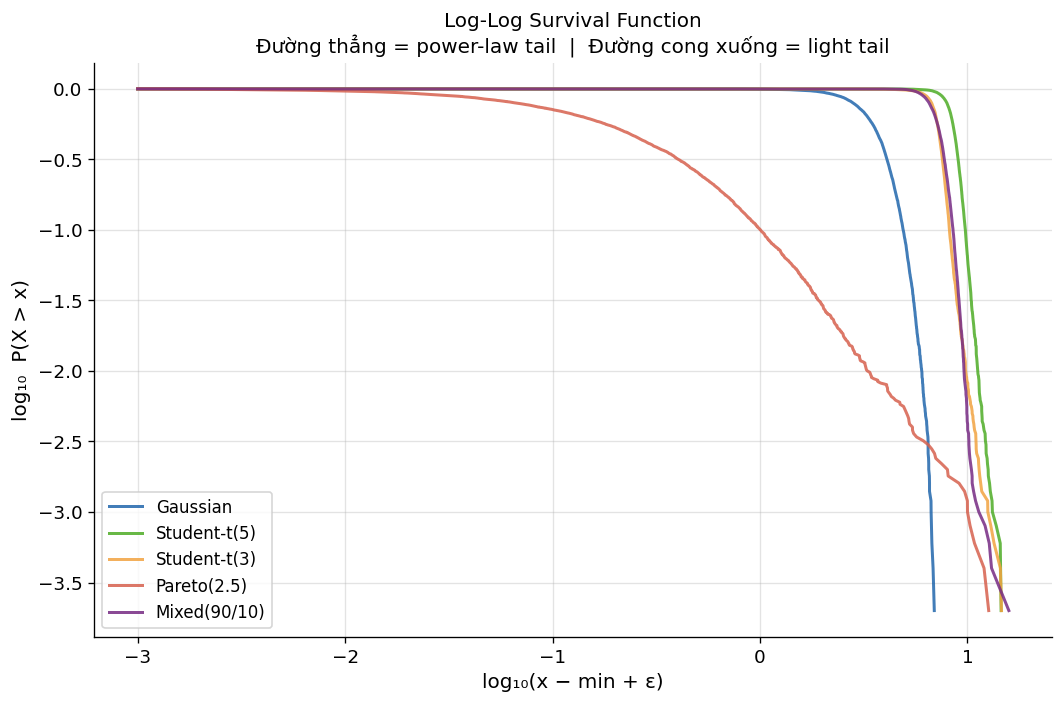

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, arr in datasets.items():
    # Dịch data để đảm bảo dương hoàn toàn cho log-log plot
    x        = arr - arr.min() + 1e-3
    sorted_x = np.sort(x)
    n        = len(sorted_x)
    survival = (n - np.arange(1, n + 1)) / n
    mask     = survival > 0
    ax.plot(
        np.log10(sorted_x[mask]),
        np.log10(survival[mask]),
        lw=1.8, alpha=0.85,
        color=COLORS[name], label=name
    )

ax.set_xlabel("log₁₀(x − min + ε)", fontsize=12)
ax.set_ylabel("log₁₀  P(X > x)", fontsize=12)
ax.set_title("Log-Log Survival Function\nĐường thẳng = power-law tail  |  Đường cong xuống = light tail", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Nhận xét — Log-Log Survival Function (CCDF)

#### 1. Gaussian — Light Tail

- Đường cong **cong xuống rất mạnh** trên thang log-log
- Không tồn tại đoạn tuyến tính ổn định

$$
\Rightarrow \text{Decay nhanh hơn power-law (sub-exponential)}
$$

- Tail “biến mất” nhanh khi $x$ tăng

---

#### 2. Student-t — Heavy Tail (Finite $\alpha$)

- **Student-t (5)**:
  - Có xu hướng **tiệm cận tuyến tính** ở vùng tail
  - Nhưng vẫn còn độ cong nhẹ

- **Student-t (3)**:
  - Đường thẳng rõ hơn ở tail
  - Ít cong hơn so với $\nu=5$

$$
\Rightarrow \nu \downarrow \;\Rightarrow\; \text{tail dày hơn}
$$

---

#### 3. Pareto (2.5) — Power-law chuẩn

- Đường gần như **tuyến tính trên toàn vùng tail**

$$
\log P(X > x) \approx -\alpha \log x
$$

- Độ dốc ổn định → phản ánh trực tiếp:
  $$
  \alpha \approx 2.5
  $$

$$
\Rightarrow \text{Power-law tail rõ ràng nhất}
$$

---

#### 4. Mixed (90/10) — Regime Switching

- Ở vùng nhỏ:
  - Hành vi giống Gaussian (cong xuống)

- Ở vùng tail:
  - Chuyển sang gần tuyến tính
  - Bị chi phối bởi thành phần Student-t

$$
\Rightarrow \text{Tail behavior bị quyết định bởi phần heavy-tail}
$$

---

### Kết luận

- **Log-log CCDF** phân tách rõ hai lớp:

  - **Light-tail**:
    $$
    \text{Gaussian} \rightarrow \text{curved}
    $$

  - **Heavy-tail**:
    $$
    \text{Student-t, Pareto} \rightarrow \text{linear (tail)}
    $$

- **Pareto** là chuẩn power-law
- **Student-t** là dạng gần power-law (asymptotic)
- **Mixture** cho thấy:
  $$
  \text{chỉ cần một phần nhỏ heavy-tail cũng đủ chi phối tail}
  $$

### 4.3 Normal QQ Plot

**Normal QQ plot** so sánh **empirical quantiles** của dữ liệu với **theoretical quantiles** của phân phối Gaussian:

$$
Q_{\text{empirical}}(p) \;\text{vs}\; Q_{\mathcal{N}(0,1)}(p)
$$

- Trục hoành: quantile lý thuyết từ $\mathcal{N}(0,1)$
- Trục tung: quantile thực nghiệm từ dữ liệu

---

### Đường tham chiếu

- Đường 45°:
  $$
  y = x
  $$

- Nếu dữ liệu tuân theo Gaussian:
  $$
  Q_{\text{empirical}}(p) \approx Q_{\mathcal{N}}(p)
  $$
  $\Rightarrow$ các điểm nằm dọc theo đường thẳng này

---

### Hành vi ở tail

- **Deviation ở hai đầu (tails)** là tín hiệu quan trọng:

  - **Upper tail (bên phải)**:
    $$
    Q_{\text{empirical}} > Q_{\text{Gaussian}}
    $$
    $\Rightarrow$ tail phải nặng hơn Gaussian

  - **Lower tail (bên trái)**:
    $$
    Q_{\text{empirical}} < Q_{\text{Gaussian}}
    $$
    $\Rightarrow$ tail trái nặng hơn

---

### Pattern điển hình

- **Gaussian**:
  - Các điểm nằm sát đường $y = x$ trên toàn miền

- **Heavy-tailed distributions**:
  - Phần giữa (center) gần tuyến tính
  - Hai đầu cong ra ngoài (S-shape):

    $$
    \text{tails “bẻ cong” khỏi đường thẳng}
    $$

- **Pareto / Student-t (df nhỏ)**:
  - Deviation mạnh ở tail
  - Khoảng cách tăng nhanh khi $|x|$ lớn

- **Mixed distribution**:
  - Gần Gaussian ở trung tâm
  - Lệch rõ ở tail

---

### Ý nghĩa

- QQ plot cung cấp:
  - Kiểm định trực quan giả định Gaussian
  - Phát hiện **tail heaviness**
  - Định tính mức độ lệch khỏi normality

$$
\Rightarrow \text{Deviation ở tail = dấu hiệu trực tiếp của tail risk}
$$

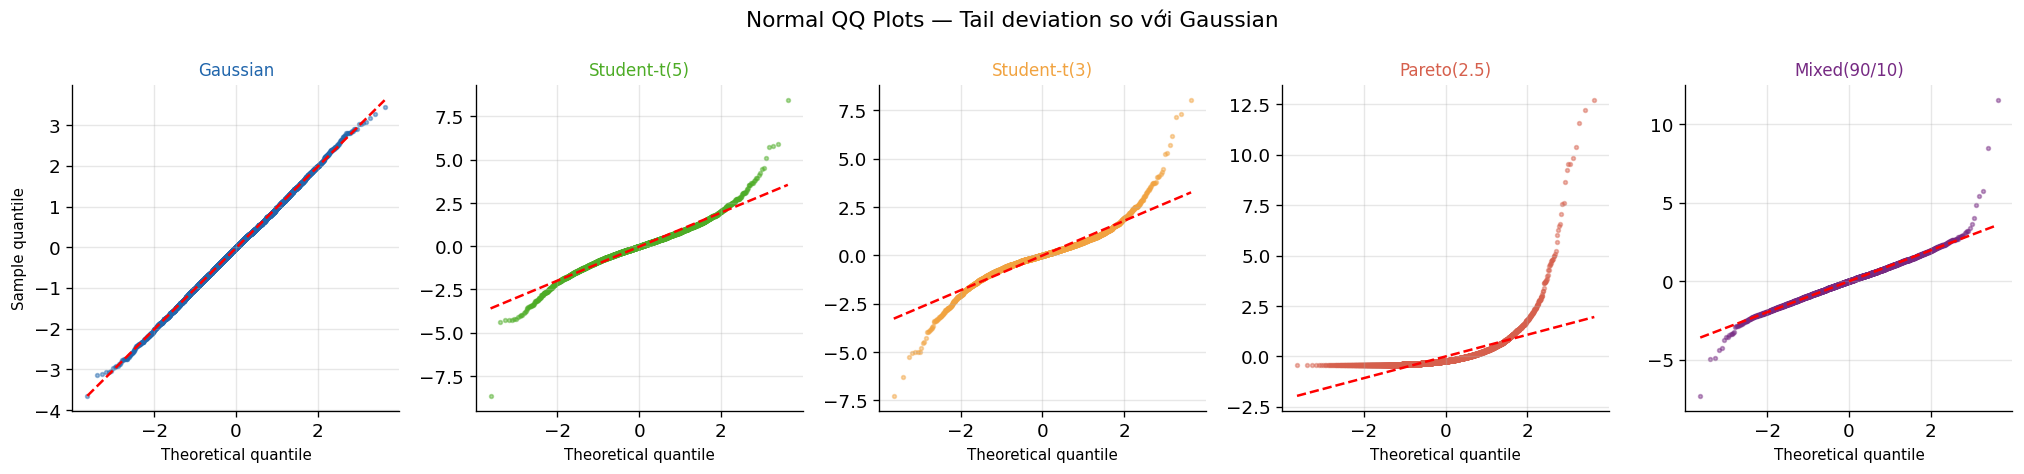

In [6]:
fig, axes = plt.subplots(1, len(datasets), figsize=(17, 4), sharey=False)

for ax, (name, arr) in zip(axes, datasets.items()):
    (osm, osr), (slope, intercept, _) = stats.probplot(arr, dist="norm", fit=True)
    ax.scatter(osm, osr, s=5, alpha=0.45, color=COLORS[name])
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, "r--", lw=1.5)
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.set_xlabel("Theoretical quantile", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("Sample quantile", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Normal QQ Plots — Tail deviation so với Gaussian", fontsize=13)
plt.tight_layout()
plt.show()

### Nhận xét — Normal QQ Plot

#### 1. Gaussian

- Các điểm bám sát đường:
  $$
  y = x
  $$
- Không có deviation ở tail

$$
\Rightarrow \text{Phân phối gần như Gaussian hoàn hảo}
$$

---

#### 2. Student-t (5)

- Trung tâm:
  - Gần tuyến tính

- Tail:
  - Hai đầu cong ra ngoài
  - Upper tail nằm trên đường $y=x$

$$
\Rightarrow \text{Tail dày hơn Gaussian}
$$

---

#### 3. Student-t (3)

- Deviation mạnh hơn $t(5)$:
  - Hai đầu cong rõ rệt
  - Điểm ở tail lệch xa khỏi đường thẳng

$$
\Rightarrow \text{Heavy tail rõ rệt}
$$

---

#### 4. Pareto (2.5)

- Lệch cực mạnh ở upper tail:

  $$
  Q_{\text{empirical}} \gg Q_{\text{Gaussian}}
  $$

- Hầu hết điểm:
  - Không nằm gần đường $y=x$
  - Phân phối bị kéo dài mạnh về phía phải

$$
\Rightarrow \text{Extreme heavy-tail, dominated bởi outliers}
$$

---

#### 5. Mixed (90/10)

- Trung tâm:
  - Gần Gaussian

- Tail:
  - Bắt đầu lệch ra ngoài
  - Upper tail cao hơn đáng kể

$$
\Rightarrow \text{Tail bị chi phối bởi thành phần heavy-tail}
$$

---

### Kết luận

- Pattern chung:

$$
\text{Gaussian} \rightarrow \text{linear}
\quad;\quad
\text{Heavy-tail} \rightarrow \text{convex deviation}
$$

- Mức độ lệch tăng dần:

$$
\text{Gaussian} < t(5) < t(3) < \text{Mixed} < \text{Pareto}
$$

$$
\Rightarrow \text{QQ plot thể hiện trực tiếp mức độ tail risk}
$$

## 5. Tail Mass Comparison

Để định lượng trực tiếp **tail risk**, ta đo xác suất vượt ngưỡng:

$$
P(|X| > k\sigma), \quad k \in \{2, 3, 4\}
$$

Đây là các mức mà dưới giả định **Gaussian** được xem là cực kỳ hiếm.

---

### Gaussian baseline

Với $X \sim \mathcal{N}(0,1)$:

- $P(|X| > 2\sigma) \approx 4.55\%$
- $P(|X| > 3\sigma) \approx 0.27\%$
- $P(|X| > 4\sigma) \approx 0.0063\%$

$$
\Rightarrow \text{Tail mass giảm theo cấp số mũ}
$$

---

### So sánh giữa các distribution

#### Student-t

- Tail mass lớn hơn Gaussian ở mọi ngưỡng
- Chênh lệch tăng mạnh khi $k$ tăng

$$
k \uparrow \;\Rightarrow\; \text{gap so với Gaussian tăng nhanh}
$$

---

#### Pareto

- Tail mass cao vượt trội ở tất cả các mức
- Không suy giảm nhanh theo $k$

$$
\Rightarrow \text{Extreme events xảy ra thường xuyên hơn nhiều}
$$

---

#### Mixed (90/10)

- Dù chỉ có 10% thành phần heavy-tail:
  $$
  P(|X| > k\sigma) \gg \text{Gaussian}
  $$
- Tail behavior bị chi phối bởi phần nhỏ này

---

### Insight cốt lõi

- Gaussian giả định:

$$
\text{Extreme events gần như không xảy ra}
$$

- Nhưng với heavy-tailed distributions:

$$
\text{Extreme events là một phần cấu trúc của dữ liệu}
$$

---

### Hệ quả trong risk modeling

- Nếu dùng Gaussian:

  $$
  VaR,\; CVaR \;\text{bị đánh giá thấp nghiêm trọng}
  $$

- Tail mass thực tế lớn hơn nhiều:

  $$
  \Rightarrow \text{Underestimation of tail risk}
  $$

---

### Kết luận

$$
\text{Không thể đánh giá risk chỉ dựa vào variance}
$$

$$
\Rightarrow \text{Tail mass là thước đo trực tiếp của extreme risk}
$$

In [7]:
sigma_levels = [2, 3, 4]
rows_tail    = []

for name, arr in datasets.items():
    row = {"Distribution": name}
    for s in sigma_levels:
        frac = float(np.mean(np.abs(arr) > s))
        row[f"|X| > {s}σ"] = f"{frac * 100:.3f}%"
    rows_tail.append(row)

# Giá trị lý thuyết của Gaussian để đối chiếu
gauss_theory = {"Distribution": "Gaussian (lý thuyết)"}
for s in sigma_levels:
    frac = 2 * (1 - stats.norm.cdf(s))
    gauss_theory[f"|X| > {s}σ"] = f"{frac * 100:.3f}%"
rows_tail.append(gauss_theory)

pd.DataFrame(rows_tail).set_index("Distribution")

,|X| > 2σ,|X| > 3σ,|X| > 4σ
Distribution,,,
Gaussian,4.660%,0.260%,0.000%
Student-t(5),4.920%,1.340%,0.380%
Student-t(3),4.460%,1.420%,0.480%
Pareto(2.5),1.920%,0.900%,0.640%
Mixed(90/10),4.100%,0.500%,0.220%
Gaussian (lý thuyết),4.550%,0.270%,0.006%


## 5. Tail Mass Comparison (Empirical Results)

Bảng dưới đây trình bày xác suất vượt ngưỡng $k\sigma$ từ dữ liệu mô phỏng:

| Distribution | $|X| > 2\sigma$ | $|X| > 3\sigma$ | $|X| > 4\sigma$ |
|---|---|---|---|
| Gaussian | $4.660\%$ | $0.260\%$ | $0.000\%$ |
| Student-t (5) | $4.920\%$ | $1.340\%$ | $0.380\%$ |
| Student-t (3) | $4.460\%$ | $1.420\%$ | $0.480\%$ |
| Pareto (2.5) | $1.920\%$ | $0.900\%$ | $0.640\%$ |
| Mixed (90/10) | $4.100\%$ | $0.500\%$ | $0.220\%$ |
| Gaussian (lý thuyết) | $4.550\%$ | $0.270\%$ | $0.006\%$ |

---

### Nhận xét

#### 1. Gaussian vs lý thuyết

- Kết quả thực nghiệm gần khớp với lý thuyết:
  $$
  P(|X| > k\sigma)_{\text{empirical}} \approx P(|X| > k\sigma)_{\text{theoretical}}
  $$

---

#### 2. Student-t — tail amplification

- Ở $3\sigma$:
  $$
  \sim 1.3\% - 1.4\% \; \text{vs} \; 0.27\% \; (\text{Gaussian})
  $$

- Ở $4\sigma$:
  $$
  \sim 0.38\% - 0.48\% \; \text{vs} \; 0.006\%
  $$

$$
\Rightarrow \text{Tail mass lớn hơn hàng chục lần}
$$

- $t(3)$ nặng tail hơn $t(5)$:
  $$
  \nu \downarrow \;\Rightarrow\; \text{tail mass} \uparrow
  $$

---

#### 3. Pareto — extreme tail dominance

- Ở $2\sigma$:
  - Thấp hơn Gaussian do phân phối lệch mạnh

- Nhưng ở $4\sigma$:
  $$
  0.640\% \gg 0.006\%
  $$

$$
\Rightarrow \text{Tail cực dày, dominated bởi extreme values}
$$

---

#### 4. Mixed — small contamination, large effect

- Chỉ 10% heavy-tail nhưng:

  - $3\sigma$: $0.500\%$ (gấp ~2 lần Gaussian)
  - $4\sigma$: $0.220\%$ (gấp ~35 lần Gaussian)

$$
\Rightarrow \text{Tail bị chi phối bởi phần nhỏ heavy-tail}
$$

---

### Insight cốt lõi

- Ở vùng $2\sigma$:
  $$
  \text{Các distribution khá giống nhau}
  $$

- Nhưng ở $3\sigma$ và $4\sigma$:
  $$
  \text{Sự khác biệt bùng nổ theo cấp số nhân}
  $$

---

### Kết luận

- Gaussian giả định:

  $$
  P(|X| > 4\sigma) \approx 0
  $$

- Thực tế (heavy-tail):

  $$
  P(|X| > 4\sigma) \gg 0
  $$

$$
\Rightarrow \text{Gaussian severely underestimates extreme risk}
$$

---
## 6. Save Datasets

Lưu toàn bộ các **dataset** đã sinh vào một file **Parquet** để các notebook tiếp theo tái sử dụng mà không cần sinh lại.

In [8]:
import os

OUTPUT_DIR = "../data/generated"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_out   = pd.DataFrame({name: arr for name, arr in datasets.items()})
out_path = os.path.join(OUTPUT_DIR, "synthetic_distributions.parquet")
df_out.to_parquet(out_path, index=False)

print(f"Saved : {out_path}")
print(f"Shape : {df_out.shape}")
df_out.head(3)

Saved : ../data/generated\synthetic_distributions.parquet
Shape : (5000, 5)


,Gaussian,Student-t(5),Student-t(3),Pareto(2.5),Mixed(90/10)
0,0.304717,0.379305,0.356494,-0.374810,-0.642450
1,-1.039984,0.749802,0.581023,-0.185492,-0.352042
2,0.750451,-0.019289,-0.017393,-0.405033,0.472969


- $5000$ samples cho mỗi distribution
- $5$ cột tương ứng với các phân phối:

  - Gaussian
  - Student-t ($\nu=5$)
  - Student-t ($\nu=3$)
  - Pareto ($\alpha=2.5$)
  - Mixed (90/10)

---

### Sample preview

| Index | Gaussian | Student-t (5) | Student-t (3) | Pareto (2.5) | Mixed (90/10) |
|---|---|---|---|---|---|
| 0 | $0.3047$ | $0.3793$ | $0.3565$ | $-0.3748$ | $-0.6425$ |
| 1 | $-1.0398$ | $0.7498$ | $0.5810$ | $-0.1855$ | $-0.3520$ |
| 2 | $0.7505$ | $-0.0193$ | $-0.0174$ | $-0.4050$ | $0.4730$ |

---

### Đặc điểm dữ liệu

- Mỗi cột là một chuỗi **i.i.d samples** từ distribution tương ứng
- Dữ liệu đã được:
  $$
  \text{demean + rescale} \;\Rightarrow\; \mathbb{E}[X] \approx 0,\; \mathrm{Var}(X) \approx 1
  $$

- Có thể sử dụng trực tiếp cho:
  - **EDA**
  - **Tail analysis (EVT, CCDF, QQ plot)**
  - **Monte Carlo simulation**
  - **Risk metrics (VaR, CVaR)**

---

### Ghi chú

- Dữ liệu **Pareto** và **Student-t (3)** vẫn giữ đặc tính:
  $$
  \text{heavy-tail} \Rightarrow \text{extreme values xuất hiện rõ rệt}
  $$

- Dataset được thiết kế để:
  $$
  \text{isolate tail effects while keeping mean \& variance fixed}
  $$

## 7. Summary

Trong notebook này, chúng ta đã xây dựng một pipeline hoàn chỉnh để cô lập và phân tích **tail behavior**:

---

### 1. Data generation

- Sinh $5{,}000$ mẫu cho mỗi distribution:
  - Gaussian
  - Student-t ($\nu = 5,\; 3$)
  - Pareto ($\alpha = 2.5$)
  - Mixed (90% Gaussian + 10% Student-t)

- Chuẩn hóa toàn bộ dữ liệu:

$$
\mathbb{E}[X] \approx 0, \quad \mathrm{Var}(X) \approx 1
$$

---

### 2. Control of lower-order moments

- Xác nhận tất cả distribution có cùng:
  - Mean
  - Variance

$$
\Rightarrow \text{Loại bỏ ảnh hưởng của location và scale}
$$

- Mọi khác biệt quan sát được đến từ:
  $$
  \text{higher-order structure (tail behavior)}
  $$

---

### 3. Visual diagnostics

Thông qua các công cụ:

- **Histogram + KDE**
- **Log-log survival (CCDF)**
- **Normal QQ plot**

ta quan sát được:

- Gaussian:
  $$
  \text{thin tail, decay nhanh}
  $$

- Student-t:
  $$
  \text{heavy tail, decay chậm hơn}
  $$

- Pareto:
  $$
  \text{power-law tail rõ rệt}
  $$

- Mixed:
  $$
  \text{tail bị chi phối bởi thành phần heavy-tail}
  $$

---

### 4. Tail mass gap

Định lượng trực tiếp qua:

$$
P(|X| > k\sigma), \quad k = 2,3,4
$$

- Gaussian:
  $$
  P(|X| > 4\sigma) \approx 0
  $$

- Heavy-tail:
  $$
  P(|X| > 4\sigma) \gg 0
  $$

$$
\Rightarrow \text{Extreme events bị đánh giá thấp nghiêm trọng nếu dùng Gaussian}
$$

---

### Insight tổng thể

- Hai distribution có thể:

$$
\text{same mean, same variance}
$$

nhưng:

$$
\text{tail risk khác nhau theo cấp số nhân}
$$

- Tail behavior là yếu tố quyết định trong:
  - $VaR$
  - $CVaR$
  - Stress testing

---

## Next

**02_distribution_fitting.ipynb**

- Fit các **parametric models** vào dữ liệu
- So sánh bằng:

$$
AIC,\; BIC
$$

- Đánh giá khả năng capture **tail behavior** của từng model